# Raw Data Inspection

This notebook contains the initial inspection of archival CCD observations
obtained from the NSF NOIRLab Astro Data Archive.

The selected science exposure corresponds to the target **158P**, observed
with the **CTIO 0.9 m telescope** using the **Tek2K_3 CCD detector** in the
**r band**.

The calibration dataset contains:

- 10 zero/bias frames
- 5 R-band dome flats
- 1 science exposure

No dark frames were available for the selected observing night.

The goal of this notebook is to inspect the FITS structure, metadata,
dimensions, image statistics, and raw detector images before applying
any calibration corrections.

In [2]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from astropy.io import fits

In [3]:
# Carpeta raíz del proyecto
PROJECT_DIR = Path("..").resolve()

# Carpetas con los datos
BIAS_DIR = PROJECT_DIR / "Bias"
FLAT_DIR = PROJECT_DIR / "Flats"

print("Proyecto:", PROJECT_DIR)
print("Bias:", BIAS_DIR)
print("Flats:", FLAT_DIR)

Proyecto: C:\Users\rodri\NoirLab
Bias: C:\Users\rodri\NoirLab\Bias
Flats: C:\Users\rodri\NoirLab\Flats


In [4]:
bias_files = sorted(list(BIAS_DIR.glob("*.fits*")))
flat_files = sorted(list(FLAT_DIR.glob("*.fits*")))

print(f"Número de bias encontrados: {len(bias_files)}")
print(f"Número de flats encontrados: {len(flat_files)}")

Número de bias encontrados: 10
Número de flats encontrados: 5


In [5]:
print("\nBias:")
for file in bias_files:
    print(file.name)

print("\nFlats:")
for file in flat_files:
    print(file.name)


Bias:
c09i_180418_204529_zri.fits.fz
c09i_180418_204803_zri.fits.fz
c09i_180418_204930_zri.fits.fz
c09i_180418_205056_zri.fits.fz
c09i_180418_205223_zri.fits.fz
c09i_180418_205350_zri.fits.fz
c09i_180418_205516_zri.fits.fz
c09i_180418_205643_zri.fits.fz
c09i_180418_205809_zri.fits.fz
c09i_180418_205936_zri.fits.fz

Flats:
c09i_180418_210818_fri.fits.fz
c09i_180418_211222_fri.fits.fz
c09i_180418_211549_fri.fits.fz
c09i_180418_211916_fri.fits.fz
c09i_180418_212242_fri.fits.fz


In [6]:
science_candidates = sorted(PROJECT_DIR.glob("*.fits*"))

print("Science candidates:")

for file in science_candidates:
    print(file.name)

Science candidates:
c09i_180419_050252_ori.fits.fz


In [7]:
science_file = science_candidates[0]

print("Science file:")
print(science_file)

Science file:
C:\Users\rodri\NoirLab\c09i_180419_050252_ori.fits.fz


In [8]:
with fits.open(science_file) as hdul:
    hdul.info()

Filename: C:\Users\rodri\NoirLab\c09i_180419_050252_ori.fits.fz
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      30   ()      
  1  COMPRESSED_IMAGE    1 CompImageHDU    118   (2168, 2048)   int16 (rescales to uint16)   


In [9]:
def get_image_hdu(filename):
    """
    Return the first HDU containing image data.
    """
    
    with fits.open(filename) as hdul:
        for i, hdu in enumerate(hdul):
            if hdu.data is not None and hdu.data.ndim == 2:
                return i
    
    raise ValueError(f"No 2D image found in {filename}")

In [10]:
science_hdu = get_image_hdu(science_file)

print("Science image HDU:", science_hdu)

Science image HDU: 1


In [11]:
with fits.open(science_file) as hdul:
    science_data = hdul[science_hdu].data.astype(float)
    science_header = hdul[science_hdu].header

In [12]:
print("Shape:", science_data.shape)

Shape: (2048, 2168)


In [13]:
keywords = [
    "OBJECT",
    "IMAGETYP",
    "DATE-OBS",
    "EXPTIME",
    "DETECTOR",
    "CCDSUM",
    "FILTER1",
    "FILTER2",
    "FILTERS"
]

for key in keywords:
    print(f"{key:10s}: {science_header.get(key, 'Not found')}")

OBJECT    : 158P
IMAGETYP  : object
DATE-OBS  : 2018-04-19T05:02:52.157
EXPTIME   : 60.0
DETECTOR  : Tek2K_3
CCDSUM    : 1 1
FILTER1   : dia
FILTER2   : r
FILTERS   : dia r


In [14]:
print(f"Minimum : {np.nanmin(science_data):.2f} ADU")
print(f"Maximum : {np.nanmax(science_data):.2f} ADU")
print(f"Mean    : {np.nanmean(science_data):.2f} ADU")
print(f"Median  : {np.nanmedian(science_data):.2f} ADU")
print(f"Std     : {np.nanstd(science_data):.2f} ADU")

Minimum : 879.00 ADU
Maximum : 62759.00 ADU
Mean    : 1269.51 ADU
Median  : 1226.00 ADU
Std     : 1550.10 ADU


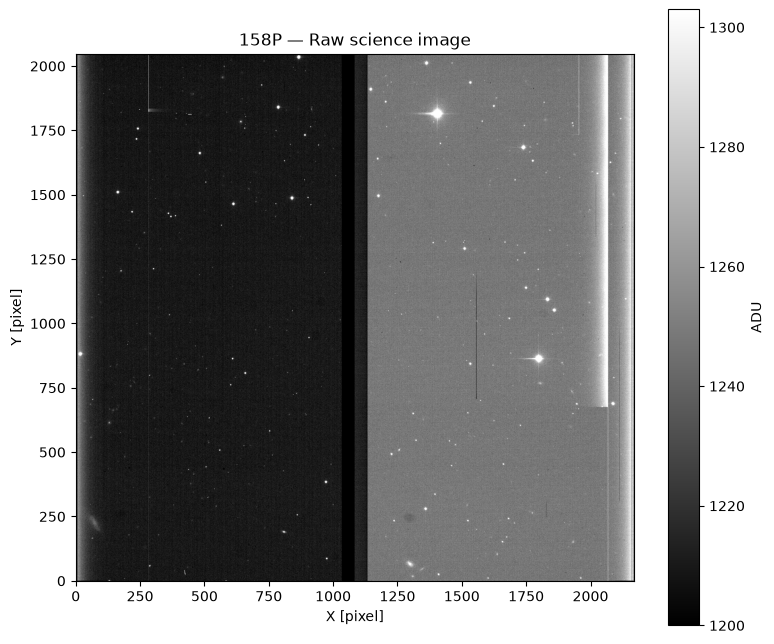

In [15]:
vmin, vmax = np.nanpercentile(science_data, [5, 99.5])

plt.figure(figsize=(9, 8))

plt.imshow(
    science_data,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label="ADU")
plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.title("158P — Raw science image")

plt.show()

## Revisamos un bias ahora

In [16]:
bias_file = bias_files[0]

bias_hdu = get_image_hdu(bias_file)

with fits.open(bias_file) as hdul:
    bias_data = hdul[bias_hdu].data.astype(float)
    bias_header = hdul[bias_hdu].header

In [17]:
print("OBJECT:", bias_header.get("OBJECT"))
print("IMAGETYP:", bias_header.get("IMAGETYP"))
print("EXPTIME:", bias_header.get("EXPTIME"))
print("DETECTOR:", bias_header.get("DETECTOR"))
print("CCDSUM:", bias_header.get("CCDSUM"))
print("Shape:", bias_data.shape)

OBJECT: Bias
IMAGETYP: zero
EXPTIME: 0.0
DETECTOR: Tek2K_3
CCDSUM: 1 1
Shape: (2048, 2168)


## Visualizamos el Bias

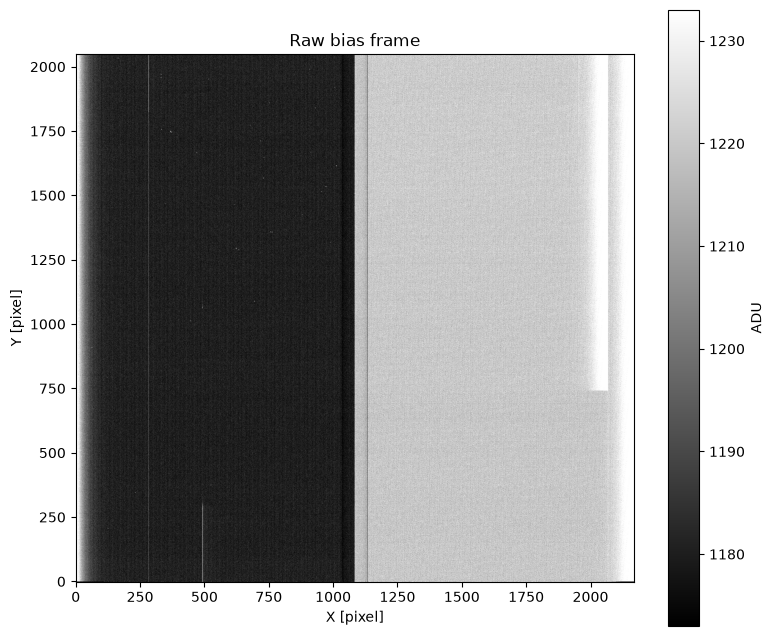

In [18]:
vmin, vmax = np.nanpercentile(bias_data, [5, 95])

plt.figure(figsize=(9, 8))

plt.imshow(
    bias_data,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label="ADU")
plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.title("Raw bias frame")

plt.show()

## Revisamos un Flat

In [19]:
flat_file = flat_files[0]

flat_hdu = get_image_hdu(flat_file)

with fits.open(flat_file) as hdul:
    flat_data = hdul[flat_hdu].data.astype(float)
    flat_header = hdul[flat_hdu].header

In [20]:
print("OBJECT:", flat_header.get("OBJECT"))
print("IMAGETYP:", flat_header.get("IMAGETYP"))
print("EXPTIME:", flat_header.get("EXPTIME"))
print("FILTER2:", flat_header.get("FILTER2"))
print("DETECTOR:", flat_header.get("DETECTOR"))
print("CCDSUM:", flat_header.get("CCDSUM"))
print("Shape:", flat_data.shape)

OBJECT: R-dflat
IMAGETYP: dflat
EXPTIME: 120.0
FILTER2: r
DETECTOR: Tek2K_3
CCDSUM: 1 1
Shape: (2048, 2168)


## Lo visualizamos tambien

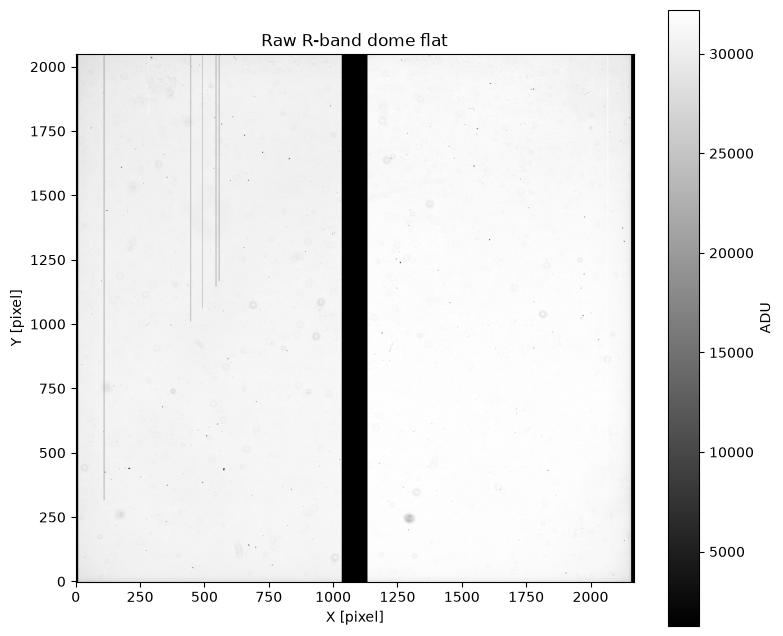

In [21]:
vmin, vmax = np.nanpercentile(flat_data, [5, 95])

plt.figure(figsize=(9, 8))

plt.imshow(
    flat_data,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)

plt.colorbar(label="ADU")
plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.title("Raw R-band dome flat")

plt.show()